# <center>Motivação</center>

<p>Garantir que o pré-treinamento do vgg19 possa ocorrer considerando um <code>UpSampling2D</code>. A máquina local não pode suportar tanta conta assim, o que torna impossível o treinamento.</p>

## 1) Importar bibliotecas

In [1]:
from tensorflow.keras.applications.efficientnet_v2 import EfficientNetV2B2, preprocess_input
# import VGG19, preprocess_input
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np


In [2]:
tf.__version__

'2.19.0'

## 2) Importar base de dados

In [3]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(50000, 32, 32, 3)
(50000, 1)
(10000, 32, 32, 3)
(10000, 1)


In [4]:
classes = {
    0: "airplane",
    1: "automobile",
    2: "bird",
    3: "cat",
    4: "deer",
    5: "dog",
    6: "frog",
    7: "horse",
    8: "ship",
    9: "truck",
}

## 3) Definir funções de treino e teste

### 3.1) <code>early_stopping</code>

In [5]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    min_delta = 1E-4,
    patience = 5,
    verbose = 1,
    monitor = "val_loss",
)

### 3.2) <code>model_compile</code>

In [6]:
model_compile = {
    "optimizer": tf.keras.optimizers.Adam(1E-4),
    "loss": tf.keras.losses.SparseCategoricalCrossentropy(),
    "metrics": tf.keras.metrics.SparseCategoricalAccuracy()
}

## 4) Treinando modelo

### 4.1) Invocando base_model

<p>Vamos importar um modelo pré-treinado <code>vgg19</code>, capaz de interpretar melhor imagens referentes aos <code>ciffar10</code> com facilidade.</p>

In [7]:
base_model = EfficientNetV2B2(
  include_top = False,
  weights = 'imagenet',
  # Segundo documentação, EfficientNetV2B2 foi treinado
  # com imagens de shape (260, 260, 3):
  input_shape = (260, 260, 3),
)

base_model.trainable = False

base_model.summary()

Model: "efficientnetv2-b2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 260, 260,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 260, 260,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 260, 260,  │          0 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 130, 130,  │        864 │ normalization[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 130, 130,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 130, 130,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 130, 130,  │      4,608 │ stem_activation[… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_bn  │ (None, 130, 130,  │         64 │ block1a_project_… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_ac… │ (None, 130, 130,  │          0 │ block1a_project_… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1b_project_co… │ (None, 130, 130,  │      2,304 │ block1a_project_… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1b_project_bn  │ (None, 130, 130,  │         64 │ block1b_project_… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1b_project_ac… │ (None, 130, 130,  │          0 │ block1b_project_… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1b_drop        │ (None, 130, 130,  │          0 │ block1b_project_… │
│ (Dropout)           │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1b_add (Add)   │ (None, 130, 130,  │          0 │ block1b_drop[0][… │
│                     │ 16)               │            │ block1a_project_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_conv │ (None, 65, 65,    │      9,216 │ block1b_add[0][0] │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_bn   │ (None, 65, 65,    │        256 │ block2a_expand_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_act… │ (None, 65, 65,    │          0 │ block2a_expand_b

 Total params: 8,769,374 (33.45 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 8,769,374 (33.45 MB)

### 4.2) Definindo modelo

In [8]:
model = tf.keras.Sequential([

    tf.keras.layers.InputLayer(
        shape = (32, 32, 3)
    ),

    # Como temos imagens com formatos (32, 32, 3), precisamos
    # garantir que o modelo consiga passar para o base_model (EfficientNetV2B2)
    # as mesmas dimensões em que foi treinado (MUITO PESADO):
    tf.keras.layers.Resizing(height = 260, width = 260, interpolation = 'bilinear'),

    base_model,
    tf.keras.layers.GlobalMaxPooling2D(),

    tf.keras.layers.Dense(4096, activation = "relu"),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(4096, activation = "relu"),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense( units = 10, activation = "softmax", )
])

model.compile(
    optimizer = model_compile["optimizer"],
    loss = model_compile["loss"],
    metrics = [model_compile["metrics"]],
)

model.summary(show_trainable = True)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ resizing (Resizing)         │ (None, 260, 260, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ efficientnetv2-b2           │ (None, 9, 9, 1408)    │  8,769,374 │   N   │
│ (Functional)                │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ global_max_pooling2d        │ (None, 1408)          │          0 │   -   │
│ (GlobalMaxPooling2D)        │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense (Dense)               │ (None, 4096)          │  5,771,264 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout (Dropout)           │ (None, 4096)          │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_1 (Dense)             │ (None, 4096)          │ 16,781,312 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout_1 (Dropout)         │ (None, 4096)          │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_2 (Dense)             │ (None, 10)            │     40,970 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 31,362,920 (119.64 MB)

 Trainable params: 22,593,546 (86.19 MB)

 Non-trainable params: 8,769,374 (33.45 MB)

### 3.3) Fit do modelo

In [9]:
history = model.fit(
    x = preprocess_input(X_train),
    y = y_train,
    batch_size = 256,
    epochs = 30,
    validation_split = 0.2,
    callbacks = [early_stopping]
)

Epoch 1/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 215s 961ms/step - loss: 0.9908 - sparse_categorical_accuracy: 0.7122 - val_loss: 0.3997 - val_sparse_categorical_accuracy: 0.8645
Epoch 2/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 95s 603ms/step - loss: 0.5735 - sparse_categorical_accuracy: 0.8062 - val_loss: 0.3619 - val_sparse_categorical_accuracy: 0.8782
Epoch 3/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 95s 603ms/step - loss: 0.5204 - sparse_categorical_accuracy: 0.8235 - val_loss: 0.3636 - val_sparse_categorical_accuracy: 0.8754
Epoch 4/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 95s 603ms/step - loss: 0.4859 - sparse_categorical_accuracy: 0.8355 - val_loss: 0.3471 - val_sparse_categorical_accuracy: 0.8794
Epoch 5/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 95s 604ms/step - loss: 0.4582 - sparse_categorical_accuracy: 0.8438 - val_loss: 0.3502 - val_sparse_categorical_accuracy: 0.8798
Epoch 6/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 95s 604ms/step - loss: 0.4409 - sparse_categorical_accuracy: 0.8504 - val_loss: 0.3217 - val_sparse_categorical_ac

In [10]:
# Conferindo performance do primeiro treinamento:
model.evaluate(
    preprocess_input(X_test), y_test
)

313/313 ━━━━━━━━━━━━━━━━━━━━ 35s 65ms/step - loss: 0.2833 - sparse_categorical_accuracy: 0.9065


[0.2832876443862915, 0.906499981880188]

### 3.4) Qualidade do modelo

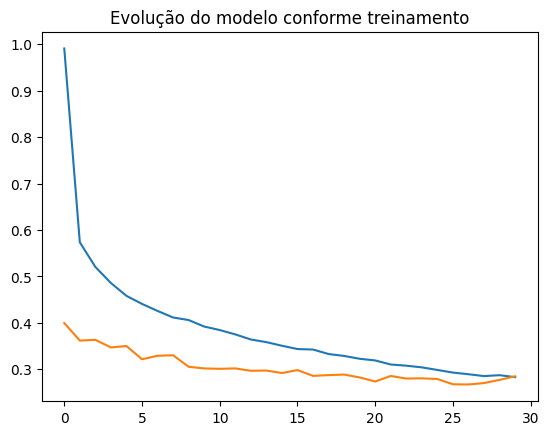

In [11]:
fig, ax = plt.subplots()

ax.plot(
  history.epoch,
  history.history['loss']
)
ax.plot(
    history.epoch,
    history.history["val_loss"]
)

plt.title("Evolução do modelo conforme treinamento")
plt.show()

### 3.5) Fining tunning

<p>Apesar de parecer que treinamos o modelo duas vezes (ou melhor, as camadas dense duas vezes - o que foi), é necessário o treinamento inicial dessas camadas porque, caso contrário, o feedback que elas passariam para todo o corpo da CNN seria tão ruim nas primeiras etapas de aprendizado que todo o <code>EfficientNetV2B2</code> iria perder sua precisão em detrimento das falhas das últimas camadas.

Assim posto, precisamento agora retreinar o modelo - <i>fine tunning</i> - de forma que a incipiência das camadas dense não prejudique tanto o modelo.</p>

#### 3.5.1) Reconfigurar <code>base_model</code>

In [12]:
# Portanto, redefinir base_model.trainable para treinamento:
base_model.trainable = True
model.summary(show_trainable = True)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ resizing (Resizing)         │ (None, 260, 260, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ efficientnetv2-b2           │ (None, 9, 9, 1408)    │  8,769,374 │   Y   │
│ (Functional)                │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ global_max_pooling2d        │ (None, 1408)          │          0 │   -   │
│ (GlobalMaxPooling2D)        │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense (Dense)               │ (None, 4096)          │  5,771,264 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout (Dropout)           │ (None, 4096)          │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_1 (Dense)             │ (None, 4096)          │ 16,781,312 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout_1 (Dropout)         │ (None, 4096)          │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_2 (Dense)             │ (None, 10)            │     40,970 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 76,550,014 (292.02 MB)

 Trainable params: 31,280,632 (119.33 MB)

 Non-trainable params: 82,288 (321.44 KB)

 Optimizer params: 45,187,094 (172.38 MB)

#### 3.5.2) Treinar novamente

<p>Aqui, treinamos novamente considerando as novas camadas dense treinadas já anteriormente com <code>base_model.treinable = False</code>.</p>

In [13]:
history_v2 = model.fit(
    x = preprocess_input(X_train),
    y = y_train,
    epochs = 50,
    batch_size = 128,
    validation_split = 0.2,
    callbacks = [early_stopping]
)

Epoch 1/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 142s 326ms/step - loss: 0.3361 - sparse_categorical_accuracy: 0.8825 - val_loss: 0.2881 - val_sparse_categorical_accuracy: 0.8984
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 93s 299ms/step - loss: 0.3228 - sparse_categorical_accuracy: 0.8875 - val_loss: 0.2739 - val_sparse_categorical_accuracy: 0.9054
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 93s 297ms/step - loss: 0.3065 - sparse_categorical_accuracy: 0.8944 - val_loss: 0.2733 - val_sparse_categorical_accuracy: 0.9064
Epoch 4/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 92s 295ms/step - loss: 0.2993 - sparse_categorical_accuracy: 0.8943 - val_loss: 0.2787 - val_sparse_categorical_accuracy: 0.9025
Epoch 5/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 92s 295ms/step - loss: 0.2936 - sparse_categorical_accuracy: 0.8983 - val_loss: 0.2859 - val_sparse_categorical_accuracy: 0.9008
Epoch 5: early stopping


#### 3.5.4) Verificar qualidade do treinamento.

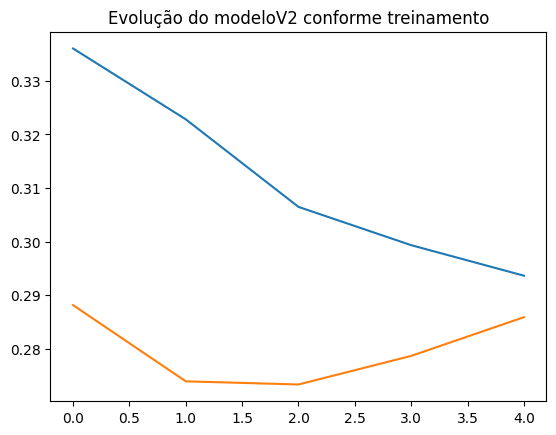

In [14]:
fig, ax = plt.subplots()

ax.plot(
  history_v2.epoch,
  history_v2.history['loss']
)
ax.plot(
    history_v2.epoch,
    history_v2.history["val_loss"]
)

plt.title("Evolução do modeloV2 conforme treinamento")
plt.show()

#### 3.5.5) Evaluate

In [15]:
model.evaluate(
    preprocess_input(X_test),
    y_test
)

313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 64ms/step - loss: 0.2870 - sparse_categorical_accuracy: 0.9020


[0.28702908754348755, 0.9020000100135803]

### 3.6) Salvar modelo

In [16]:
model.save("./drive/MyDrive/models/cifar10.keras")